In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, average_precision_score, roc_curve, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler

from math import sqrt

def roc_auc_ci(y_true, y_score, positive=1):
    AUC = roc_auc_score(y_true, y_score)
    N1 = sum(y_true == positive)
    N2 = sum(y_true != positive)
    Q1 = AUC / (2 - AUC)
    Q2 = 2*AUC**2 / (1 + AUC)
    SE_AUC = sqrt((AUC*(1 - AUC) + (N1 - 1)*(Q1 - AUC**2) + (N2 - 1)*(Q2 - AUC**2)) / (N1*N2))
    lower = AUC - 1.96*SE_AUC
    upper = AUC + 1.96*SE_AUC
    if lower < 0:
        lower = 0
    if upper > 1:
        upper = 1
    return print("AUROC (95% CI)", "%.3f" % AUC, "[", "%.3f" % lower, ",", "%.3f" % upper, "]")

def roc_auprc_ci(y_true, y_score, positive=1):
    AUPRC = average_precision_score(y_true, y_score)
    N1 = sum(y_true == positive)
    N2 = sum(y_true != positive)
    Q1 = AUPRC / (2 - AUPRC)
    Q2 = 2*AUPRC**2 / (1 + AUPRC)
    SE_AUPRC = sqrt((AUPRC*(1 - AUPRC) + (N1 - 1)*(Q1 - AUPRC**2) + (N2 - 1)*(Q2 - AUPRC**2)) / (N1*N2))
    lower = AUPRC - 1.96*SE_AUPRC
    upper = AUPRC + 1.96*SE_AUPRC
    if lower < 0:
        lower = 0
    if upper > 1:
        upper = 1
    return print("AUPRC (95% CI)", "%.3f" % AUPRC, "[", "%.3f" % lower, ",", "%.3f" % upper, "]")


In [2]:
dataset = pd.read_csv('./dataset.csv', index_col='Unnamed: 0')
dataset

,ALG13.KEGG_N_GLYCAN_BIOSYNTHESIS,DOLPP1.KEGG_N_GLYCAN_BIOSYNTHESIS,RPN1.KEGG_N_GLYCAN_BIOSYNTHESIS,ALG14.KEGG_N_GLYCAN_BIOSYNTHESIS,MAN1B1.KEGG_N_GLYCAN_BIOSYNTHESIS,ALG3.KEGG_N_GLYCAN_BIOSYNTHESIS,B4GALT1.KEGG_N_GLYCAN_BIOSYNTHESIS,MGAT5.KEGG_N_GLYCAN_BIOSYNTHESIS,RPN2.KEGG_N_GLYCAN_BIOSYNTHESIS,STT3A.KEGG_N_GLYCAN_BIOSYNTHESIS,...,MYH7.KEGG_VIRAL_MYOCARDITIS,MYH6.KEGG_VIRAL_MYOCARDITIS,MYH9.KEGG_VIRAL_MYOCARDITIS,MYH8.KEGG_VIRAL_MYOCARDITIS,MYH11.KEGG_VIRAL_MYOCARDITIS,FYN.KEGG_VIRAL_MYOCARDITIS,MYH10.KEGG_VIRAL_MYOCARDITIS,HLA-DRB1.KEGG_VIRAL_MYOCARDITIS,HLA-DRA.KEGG_VIRAL_MYOCARDITIS,label
B3_P3_M15,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,4.65,0.0,0.00,0.00,0.0,9.13,14.14,1
B6_P1_M15,0.00,0.00,0.00,0.0,7.24,0.00,7.36,0.0,0.00,0.00,...,0.0,0.0,8.52,0.0,0.00,0.00,0.0,9.19,13.09,1
D7_P2_M15,9.07,0.00,7.61,0.0,0.00,7.61,7.69,0.0,0.00,6.24,...,0.0,0.0,5.95,0.0,0.00,0.00,0.0,11.46,13.66,1
E11_P2_M15,0.00,0.00,0.00,0.0,0.00,0.00,5.08,0.0,0.00,0.00,...,0.0,0.0,8.43,0.0,0.00,9.40,0.0,6.96,0.00,1
F7_P1_M15,0.00,0.00,7.50,0.0,0.00,0.00,7.23,0.0,9.21,8.24,...,0.0,0.0,8.33,0.0,0.00,4.77,0.0,8.28,0.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B10_P8_M86_L001,6.58,0.00,10.02,0.0,0.00,8.27,0.00,0.0,7.24,8.16,...,0.0,0.0,7.99,0.0,0.00,4.03,0.0,9.47,10.13,0
D1_P8_M86_L001,0.00,0.00,8.84,0.0,0.00,0.00,7.27,0.0,7.38,0.00,...,0.0,0.0,6.18,0.0,3.01,7.41,0.0,9.87,11.36,0
D7_P8_M86_L001,0.00,0.00,4.05,0.0,0.00,0.00,6.34,0.0,0.00,0.00,...,0.0,0.0,8.00,0.0,0.00,0.00,0.0,0.00,0.00,0
G7_P6_M86_L001,0.00,0.00,8.36,0.0,0.00,0.00,4.62,0.0,7.96,9.01,...,0.0,0.0,8.05,0.0,0.00,7.77,0.0,0.00,0.00,0


In [3]:
X = dataset.drop(['label'], axis=1)
y = dataset['label']

In [4]:
scalers = MinMaxScaler()
scalers.fit_transform(X)

array([[0.        , 0.        , 0.        , ..., 0.        , 0.67479675,
        0.92057292],
       [0.        , 0.        , 0.        , ..., 0.        , 0.67923134,
        0.85221354],
       [0.73859935, 0.        , 0.6868231 , ..., 0.        , 0.84700665,
        0.88932292],
       ...,
       [0.        , 0.        , 0.36552347, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.75451264, ..., 0.        , 0.        ,
        0.        ],
       [0.68892508, 0.75571003, 0.61823105, ..., 0.        , 0.65853659,
        0.66536458]])

In [5]:
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=25)

X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size=0.2, shuffle=True, stratify=y_tr, random_state=25)

In [6]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(10425, 12413)
(3258, 12413)
(2607, 12413)


In [7]:
print(y_train.shape)
print(y_test.shape)
print(y_val.shape)

(10425,)
(3258,)
(2607,)


# XGBoost

In [8]:
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

In [9]:
model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    objective="binary:logistic",
    subsample=0.8,
    max_depth=6,
    n_jobs=20,
    scale_pos_weight=3,
    importance_type="cover",
    use_label_encoder=False,
    random_state=42
)
model_xgb.fit(
    X_train, y_train, 
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    early_stopping_rounds=10,
    verbose=0)

/usr/local/lib/python3.8/dist-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/usr/local/lib/python3.8/dist-packages/xgboost/sklearn.py:835: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None,
              importance_type='cover', interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=200, n_jobs=20,
              num_parallel_tree=None, predictor=None, random_state=42, ...)

In [10]:
pred_propba_xgb = model_xgb.predict_proba(X_test)

predict_xgb = model_xgb.predict(X_test)

score_xgb = roc_auc_score(y_test, pred_propba_xgb[:,1])
auroc_xgb = roc_auc_ci(y_test, pred_propba_xgb[:,1])
auprc_xgb = roc_auprc_ci(y_test, pred_propba_xgb[:,1])
report_xgb = classification_report(y_test, predict_xgb, labels=[0, 1])
confusion_xgb = confusion_matrix(y_test, predict_xgb)

print(auroc_xgb, auprc_xgb)
print(report_xgb)
print(confusion_xgb)

AUROC (95% CI) 0.882 [ 0.868 , 0.896 ]
AUPRC (95% CI) 0.808 [ 0.791 , 0.824 ]
None None
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      2145
           1       0.67      0.79      0.73      1113

    accuracy                           0.80      3258
   macro avg       0.78      0.80      0.78      3258
weighted avg       0.81      0.80      0.80      3258

[[1718  427]
 [ 229  884]]


# Neural Networks

In [11]:
model_fnn = MLPClassifier(
    hidden_layer_sizes = (100,100,100), 
    activation = "relu", 
    max_iter = 10000, 
    solver = 'adam', 
    random_state = 1, 
    learning_rate = 'adaptive',
    learning_rate_init = 0.01,
    validation_fraction = 0.25,
    early_stopping = True,
    n_iter_no_change=30,
    verbose = 0)
model_fnn.fit(
    X_train, 
    y_train
)

pred_propba_fnn = model_fnn.predict_proba(X_test)
predict_fnn = model_fnn.predict(X_test)

score_fnn = roc_auc_score(y_test, pred_propba_fnn[:,1])
auroc_fnn = roc_auc_ci(y_test, pred_propba_fnn[:,1])
auprc_fnn = roc_auprc_ci(y_test, pred_propba_fnn[:,1])
report_fnn = classification_report(y_test, predict_fnn, labels=[0, 1])
confusion_fnn = confusion_matrix(y_test, predict_fnn)

print(auroc_fnn, auprc_fnn)
print(report_fnn)
print(confusion_fnn)

/usr/local/lib/python3.8/dist-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifi

AUROC (95% CI) 0.804 [ 0.787 , 0.821 ]
AUPRC (95% CI) 0.682 [ 0.662 , 0.702 ]
None None
              precision    recall  f1-score   support

           0       0.79      0.87      0.83      2145
           1       0.68      0.55      0.61      1113

    accuracy                           0.76      3258
   macro avg       0.74      0.71      0.72      3258
weighted avg       0.75      0.76      0.75      3258

[[1864  281]
 [ 505  608]]


# Logistic Regression

In [12]:
model_logi = LogisticRegression(
    max_iter=10000,
    solver="lbfgs",
    class_weight={0:1, 1:3}
)
model_logi.fit(
    X_train, 
    y_train
)
pred_propba_logi = model_logi.predict_proba(X_test)

predict_logi = model_logi.predict(X_test)

score_logi = roc_auc_score(y_test, pred_propba_logi[:,1])
auroc_logi = roc_auc_ci(y_test, pred_propba_logi[:,1])
auprc_logi = roc_auprc_ci(y_test, pred_propba_logi[:,1])
report_logi = classification_report(y_test, predict_logi, labels=[0, 1])
confusion_logi = confusion_matrix(y_test, predict_logi)

print(auroc_logi, auprc_logi)
print(report_logi)
print(confusion_logi)

AUROC (95% CI) 0.767 [ 0.749 , 0.785 ]
AUPRC (95% CI) 0.618 [ 0.597 , 0.639 ]
None None
              precision    recall  f1-score   support

           0       0.80      0.78      0.79      2145
           1       0.59      0.62      0.60      1113

    accuracy                           0.72      3258
   macro avg       0.69      0.70      0.69      3258
weighted avg       0.72      0.72      0.72      3258

[[1663  482]
 [ 428  685]]


# RandomForest

In [13]:
model_rf = RandomForestClassifier()

model_rf.fit(
    X_train,
    y_train
)

pred_proba_rf = model_rf.predict_proba(X_test)

predict_rf = model_rf.predict(X_test)

score_rf = roc_auc_score(y_test, pred_proba_rf[:,1])
auroc_rf = roc_auc_ci(y_test, pred_proba_rf[:,1])
auprc_rf = roc_auprc_ci(y_test, pred_proba_rf[:,1])
report_rf = classification_report(y_test, predict_rf, labels=[0, 1])
confusion_rf = confusion_matrix(y_test, predict_rf)

print(auroc_rf, auprc_rf)
print(report_rf)
print(confusion_rf)

AUROC (95% CI) 0.842 [ 0.826 , 0.857 ]
AUPRC (95% CI) 0.741 [ 0.722 , 0.759 ]
None None
              precision    recall  f1-score   support

           0       0.77      0.93      0.84      2145
           1       0.78      0.47      0.59      1113

    accuracy                           0.77      3258
   macro avg       0.78      0.70      0.71      3258
weighted avg       0.77      0.77      0.76      3258

[[1998  147]
 [ 592  521]]


# SVM

In [14]:
model_svm = SVC(kernel='linear', probability=True)
model_svm.fit(X_train, y_train)

pred_proba_svm = model_svm.predict_proba(X_test)

predict_svm = model_svm.predict(X_test)

score_svm = roc_auc_score(y_test, pred_proba_svm[:,1])
auroc_svm = roc_auc_ci(y_test, pred_proba_svm[:,1])
auprc_svm = roc_auprc_ci(y_test, pred_proba_svm[:,1])
report_svm = classification_report(y_test, predict_svm, labels=[0, 1])
confusion_svm = confusion_matrix(y_test, predict_svm)

print(auroc_svm, auprc_svm)
print(report_svm)
print(confusion_svm)

AUROC (95% CI) 0.761 [ 0.743 , 0.779 ]
AUPRC (95% CI) 0.619 [ 0.598 , 0.640 ]
None None
              precision    recall  f1-score   support

           0       0.79      0.77      0.78      2145
           1       0.58      0.61      0.59      1113

    accuracy                           0.72      3258
   macro avg       0.69      0.69      0.69      3258
weighted avg       0.72      0.72      0.72      3258

[[1659  486]
 [ 437  676]]


# 1d cnn

In [15]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # 또는 memory_limit 설정
    except RuntimeError as e:
        print(e)


In [16]:
from tensorflow import keras
from sklearn.metrics import auc, classification_report, accuracy_score

model_cnn = keras.models.load_model('./best_model.h5')

y_pred = model_cnn.predict(X_test).ravel()

In [17]:
y_pred

array([6.2512094e-01, 3.2658879e-02, 2.4701250e-05, ..., 1.4790232e-12,
       2.7069264e-14, 1.6048514e-09], dtype=float32)

In [18]:
y_pred_class = (y_pred>0.5).astype('int32')
y_pred_class

array([1, 0, 0, ..., 0, 0, 0], dtype=int32)

In [19]:
score_cnn = roc_auc_score(y_test, y_pred)
auroc_cnn = roc_auc_ci(y_test, y_pred)
auprc_cnn = roc_auprc_ci(y_test, y_pred)
report_cnn = classification_report(y_test, y_pred_class, labels=[0, 1])
confusion_cnn = confusion_matrix(y_test, y_pred_class)

print(auroc_cnn, auprc_cnn)
print(report_cnn)
print(confusion_cnn)

AUROC (95% CI) 0.810 [ 0.793 , 0.827 ]
AUPRC (95% CI) 0.676 [ 0.656 , 0.696 ]
None None
              precision    recall  f1-score   support

           0       0.76      0.88      0.81      2145
           1       0.67      0.46      0.54      1113

    accuracy                           0.74      3258
   macro avg       0.71      0.67      0.68      3258
weighted avg       0.73      0.74      0.72      3258

[[1892  253]
 [ 606  507]]


# 2d cnn

In [24]:
X_test_2d = np.load("X_test_2d_cnn.npy")
y_test_2d = np.load("y_test_2d_cnn.npy")

In [26]:
from tensorflow import keras
from sklearn.metrics import auc, classification_report, accuracy_score

model_cnn2d = keras.models.load_model('./best_model_gradcam.h5')

y_pred_2d = model_cnn2d.predict(X_test_2d).ravel()

In [28]:
y_pred_class_2d = (y_pred_2d > 0.5).astype('int32')
y_pred_class_2d

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

In [29]:
# ROC AUC 및 PR AUC, 기타 평가 지표
score_cnn2d = roc_auc_score(y_test_2d, y_pred_2d)
auroc_cnn2d = roc_auc_ci(y_test_2d, y_pred_2d)
auprc_cnn2d = roc_auprc_ci(y_test_2d, y_pred_2d)
report_cnn2d = classification_report(y_test_2d, y_pred_class_2d, labels=[0, 1])
confusion_cnn2d = confusion_matrix(y_test_2d, y_pred_class_2d)

# 출력
print("2D CNN AUROC:", auroc_cnn2d)
print("2D CNN AUPRC:", auprc_cnn2d)
print(report_cnn2d)
print(confusion_cnn2d)

AUROC (95% CI) 0.806 [ 0.789 , 0.823 ]
AUPRC (95% CI) 0.686 [ 0.666 , 0.706 ]
2D CNN AUROC: None
2D CNN AUPRC: None
              precision    recall  f1-score   support

           0       0.76      0.89      0.82      2145
           1       0.69      0.47      0.56      1113

    accuracy                           0.75      3258
   macro avg       0.73      0.68      0.69      3258
weighted avg       0.74      0.75      0.73      3258

[[1903  242]
 [ 585  528]]


# AUROC Curve

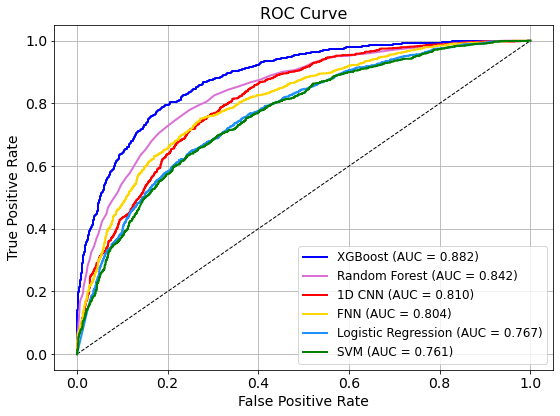

In [35]:
############ 20250325 추가 ##################
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ROC curve 계산
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, pred_propba_xgb[:,1])
fpr_fnn, tpr_fnn, _ = roc_curve(y_test, pred_propba_fnn[:,1])
fpr_logi, tpr_logi, _ = roc_curve(y_test, pred_propba_logi[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, pred_proba_rf[:,1])
fpr_svm, tpr_svm, _ = roc_curve(y_test, pred_proba_svm[:,1])
fpr_cnn1d, tpr_cnn1d, _ = roc_curve(y_test, y_pred)           # 1D CNN

# 폰트 스타일 (논문용)
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 14

# 모델 이름과 점수, FPR/TPR 리스트로 묶기
models = [
    ('XGBoost', score_xgb, fpr_xgb, tpr_xgb, 'blue'),
    ('Random Forest', score_rf, fpr_rf, tpr_rf, 'orchid'),
    ('FNN', score_fnn, fpr_fnn, tpr_fnn, 'gold'),
    ('1D CNN', score_cnn, fpr_cnn1d, tpr_cnn1d, 'red'),
    ('Logistic Regression', score_logi, fpr_logi, tpr_logi, 'dodgerblue'),
    ('SVM', score_svm, fpr_svm, tpr_svm, 'green'),
]

# AUC 기준으로 정렬
models_sorted = sorted(models, key=lambda x: x[1], reverse=True)

# Plot
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)

for name, score, fpr, tpr, color in models_sorted:
    plt.plot(fpr, tpr, label=f'{name} (AUC = {score:.3f})', linewidth=2, color=color)

plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.tight_layout()

# PDF 저장
plt.savefig("./vector_image/roc_curve.pdf", format='pdf', bbox_inches='tight')
plt.savefig("./vector_image/roc_curve.svg", format='svg', bbox_inches='tight')

plt.show()


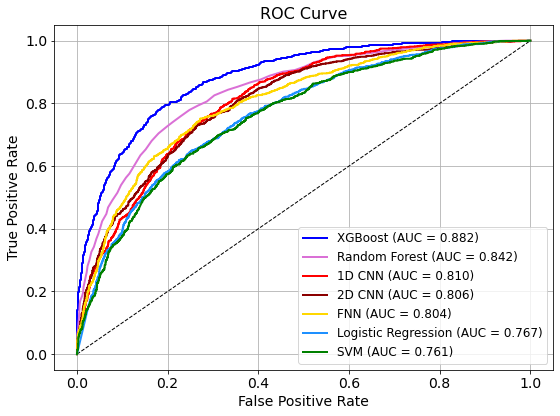

In [36]:
##############2d cnn 추가버전##################
############ 20250325 추가 ##################
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ROC curve 계산
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, pred_propba_xgb[:,1])
fpr_fnn, tpr_fnn, _ = roc_curve(y_test, pred_propba_fnn[:,1])
fpr_logi, tpr_logi, _ = roc_curve(y_test, pred_propba_logi[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, pred_proba_rf[:,1])
fpr_svm, tpr_svm, _ = roc_curve(y_test, pred_proba_svm[:,1])
fpr_cnn1d, tpr_cnn1d, _ = roc_curve(y_test, y_pred)           # 1D CNN
fpr_cnn2d, tpr_cnn2d, _ = roc_curve(y_test_2d, y_pred_2d)        # 2D CNN

# 폰트 스타일 (논문용)
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 14

# 모델 이름과 점수, FPR/TPR 리스트로 묶기
models = [
    ('XGBoost', score_xgb, fpr_xgb, tpr_xgb, 'blue'),
    ('Random Forest', score_rf, fpr_rf, tpr_rf, 'orchid'),
    ('FNN', score_fnn, fpr_fnn, tpr_fnn, 'gold'),
    ('1D CNN', score_cnn, fpr_cnn1d, tpr_cnn1d, 'red'),
    ('2D CNN', score_cnn2d, fpr_cnn2d, tpr_cnn2d, 'darkred'),
    ('Logistic Regression', score_logi, fpr_logi, tpr_logi, 'dodgerblue'),
    ('SVM', score_svm, fpr_svm, tpr_svm, 'green'),
]

# AUC 기준으로 정렬
models_sorted = sorted(models, key=lambda x: x[1], reverse=True)

# Plot
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)

for name, score, fpr, tpr, color in models_sorted:
    plt.plot(fpr, tpr, label=f'{name} (AUC = {score:.3f})', linewidth=2, color=color)

plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.tight_layout()

# PDF 저장
plt.savefig("./vector_image/roc_curve_2D_CNN.pdf", format='pdf', bbox_inches='tight')
plt.savefig("./vector_image/roc_curve_2D_CNN.svg", format='svg', bbox_inches='tight')

plt.show()


In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
plt.figure(figsize=(10, 8))
ax1 = plt.subplot2grid((3, 1), (0, 0), rowspan=2)
ax2 = plt.subplot2grid((3, 1), (2, 0))

ax1.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

prob_pos_xgb = pred_propba_xgb[:,1]
clf_score_xgb = brier_score_loss(y_test, prob_pos_xgb, pos_label=1)    
fraction_of_positives_xgb, mean_predicted_value_xgb = calibration_curve(y_test, prob_pos_xgb, n_bins=10)

prob_pos_fnn = pred_propba_fnn[:,1]
clf_score_fnn = brier_score_loss(y_test, prob_pos_fnn, pos_label=1)    
fraction_of_positives_fnn, mean_predicted_value_fnn = calibration_curve(y_test, prob_pos_fnn, n_bins=10)

prob_pos_logi = pred_propba_logi[:,1]
clf_score_logi = brier_score_loss(y_test, prob_pos_logi, pos_label=1)    
fraction_of_positives_logi, mean_predicted_value_logi = calibration_curve(y_test, prob_pos_logi, n_bins=10)

prob_pos_rf = pred_proba_rf[:,1]
clf_score_rf = brier_score_loss(y_test, prob_pos_rf, pos_label=1)    
fraction_of_positives_rf, mean_predicted_value_rf = calibration_curve(y_test, prob_pos_rf, n_bins=10)

prob_pos_svm = pred_proba_svm[:,1]
clf_score_svm = brier_score_loss(y_test, prob_pos_svm, pos_label=1)    
fraction_of_positives_svm, mean_predicted_value_svm = calibration_curve(y_test, prob_pos_svm, n_bins=10)

prob_pos_cnn = y_pred
clf_score_cnn = brier_score_loss(y_test, prob_pos_cnn, pos_label=1)    
fraction_of_positives_cnn, mean_predicted_value_cnn = calibration_curve(y_test, prob_pos_cnn, n_bins=10)

ax1.plot(mean_predicted_value_xgb, fraction_of_positives_xgb, "s-",
         label="%s (%1.3f)" % ("xgb", clf_score_xgb))
ax1.plot(mean_predicted_value_fnn, fraction_of_positives_fnn, "s-",
         label="%s (%1.3f)" % ("fnn", clf_score_fnn))
ax1.plot(mean_predicted_value_logi, fraction_of_positives_logi, "s-",
         label="%s (%1.3f)" % ("logi", clf_score_logi))
ax1.plot(mean_predicted_value_rf, fraction_of_positives_rf, "s-",
         label="%s (%1.3f)" % ("rf", clf_score_rf))
ax1.plot(mean_predicted_value_svm, fraction_of_positives_svm, "s-",
         label="%s (%1.3f)" % ("svm", clf_score_svm))
ax1.plot(mean_predicted_value_cnn, fraction_of_positives_cnn, "s-",
         label="%s (%1.3f)" % ("cnn", clf_score_cnn))

ax2.hist(prob_pos_xgb, range=(0, 1), bins=10, label="xgb",
         histtype="step", lw=2)
ax2.hist(prob_pos_fnn, range=(0, 1), bins=10, label="fnn",
         histtype="step", lw=2)
ax2.hist(prob_pos_logi, range=(0, 1), bins=10, label="logi",
         histtype="step", lw=2)
ax2.hist(prob_pos_rf, range=(0, 1), bins=10, label="rf",
         histtype="step", lw=2)
ax2.hist(prob_pos_svm, range=(0, 1), bins=10, label="svm",
         histtype="step", lw=2)
ax2.hist(prob_pos_cnn, range=(0, 1), bins=10, label="cnn",
         histtype="step", lw=2)

ax1.set_ylabel("Fraction of positives")
ax1.set_ylim([-0.05, 1.05])
ax1.legend(loc="lower right")
ax1.set_title('Calibration plots  (reliability curve)')

ax2.set_xlabel("Mean predicted value")
ax2.set_ylabel("Count")
ax2.legend(loc="upper center", ncol=2)

plt.tight_layout()
plt.show()

# Feature Importance - XGBoost

In [ ]:
feature_names = pd.DataFrame(X.columns.tolist(), columns=["Features"])
coef_xgb = pd.DataFrame(model_xgb.feature_importances_, columns=["Weights"])
coef_xgb = pd.concat([feature_names, coef_xgb], axis=1)
coef_xgb.sort_values(["Weights"], ascending=[False], inplace=True)
coef_xgb["Weights"] = (coef_xgb["Weights"] - coef_xgb["Weights"].min()) / (coef_xgb["Weights"].max() - coef_xgb["Weights"].min())
coef_xgb

In [ ]:
plt.rcParams['font.size'] = 15

plt.figure(figsize=(12,18))
sns.barplot(y="Features", x="Weights", data=coef_xgb.iloc[:50])
plt.show()

# Feature Importance - Logistic Regression

In [ ]:
coef_logi = pd.DataFrame(model_logi.coef_.T, columns=["Weights"])
col = pd.DataFrame(X.columns.tolist(), columns=["Features"])
coef_logi = pd.concat([col, coef_logi], axis=1)
#coef_logi["Weights"] = np.abs(coef_logi["Weights"])
coef_logi.sort_values(["Weights"], ascending=[False], inplace=True)
#coef_logi["Weights"] = (coef_logi["Weights"] - coef_logi["Weights"].min()) / (coef_logi["Weights"].max() - coef_logi["Weights"].min())
coef_logi

In [ ]:
plt.rcParams['font.size'] = 15

plt.figure(figsize=(12,18))
sns.barplot(y="Features", x="Weights", data=pd.concat([coef_logi.iloc[:25],coef_logi.iloc[-25:]], axis=0))
plt.show()

In [ ]:
import shap
explainer = shap.Explainer(model_xgb)
shap_values = explainer(X_test)

In [ ]:
pred_all = pd.DataFrame(pred_propba_xgb[:,1], columns=["Pred"])

# Individual Prediction 

In [ ]:
pred_all.loc[pred_all["Pred"]<0.1]

In [ ]:
check = 3
pred = pred_propba_xgb[check,1]
print("Event:", y_test.iloc[check])
print("Pred:", "%.2f" % pred)

X_test.iloc[check:check+1]

In [ ]:
shap.initjs()
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)
shap.plots.force(explainer.expected_value, 
                 shap_values[check,:], 
                 X_test.iloc[check,:],
                link="logit"
                )

In [ ]:
pred_all.loc[pred_all["Pred"]>0.7]

In [ ]:
check = 194
pred = pred_propba_xgb[check,1]
print("Event:", y_test.iloc[check])
print("Pred:", "%.2f" % pred)
    
X_test.iloc[check:check+1]

In [ ]:
shap.initjs()
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)
shap.plots.force(explainer.expected_value, 
                 shap_values[check,:], 
                 X_test.iloc[check,:],
                link="logit"
                )